---
## Exercício Final

Use a base `base_vendas_supermercado.xlsx` e siga os passos abaixo:

**1. Preparação (dados sujos)**
Crie uma cópia suja da base com:
- 10 NaN na coluna `'Categoria'`
- 8 NaN na coluna `'Quantidade'`
- 3 valores absurdos em `'Valor Líquido'` (ex: 5000, 4500, 0.01)
- 5 linhas duplicadas

**2. Diagnóstico**
Exiba:
- Percentual de NaN por coluna
- Quantidade de duplicatas

**3. Limpeza**
Aplique o pipeline completo:
- Remover duplicatas
- Preencher NaN de `'Categoria'` com a moda
- Preencher NaN de `'Quantidade'` com a mediana
- Filtrar `'Valor Líquido'` para o intervalo R$ 1 a R$ 300

**4. Transformações**
- Crie a coluna `'Mês_Num'` com o número do mês
- Crie a coluna `'Perfil_Compra'` usando `pd.cut()` com 3 faixas de `'Valor Líquido'`

**5. Gráfico final**
Plote um gráfico de barras com o total de vendas por `'Categoria'`, ordenado do maior para o menor.

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

caminho = r"C:\Users\ferna\Desktop\SCTEC-PRATICA\turma-visualizacao-de-dados\alunos\luiz_fernando_jesus\semana_06\base\base_vendas_supermercado.xlsx"

df = pd.read_excel(caminho)

c:\Users\ferna\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\ferna\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [87]:
# Criando uma versão "suja" para praticar — nunca modifique a base original!
np.random.seed(42)
df_sujo = df.copy()

nan_config = {
    "Categoria": 10,
    "Preço Unitário": 8,
}

for coluna, qtd in nan_config.items():
    idx = np.random.choice(df_sujo.index, qtd, replace=False)
    df_sujo.loc[idx, coluna] = np.nan

idx_out = np.random.choice(df_sujo.index, 3, replace=False)
df_sujo.loc[idx_out, "Valor Líquido"] = [5000, 4500, 0.01]

dup = df_sujo.sample(5, random_state=1)
df_sujo = pd.concat([df_sujo, dup], ignore_index=True)

print(
    f"Base suja criada: {df_sujo.shape[0]} linhas | {df_sujo.isnull().sum().sum()} NaN | {df_sujo.duplicated().sum()} duplicatas"
)

Base suja criada: 255 linhas | 18 NaN | 5 duplicatas


In [78]:
nan_por_coluna = df_sujo.isnull().sum()
pct_nan = (df_sujo.isnull().mean() * 100).round(1)

print(pct_nan)

print("\n=== Valores ausentes por coluna ===")
for col in df_sujo.columns:
    if nan_por_coluna[col] > 0:
        barras = "█" * int(pct_nan[col] / 2)
        print(
            f"  {col:<25} {nan_por_coluna[col]:>3} NaN  ({pct_nan[col]:>4.1f}%)  {barras}"
        )

print()
print(f"Total de NaN: {df_sujo.isnull().sum().sum()}")

Data                  0.0
Loja                  0.0
Cliente               0.0
Categoria             3.9
Produto               0.0
Quantidade            0.0
Preço Unitário        3.1
Desconto %            0.0
Valor Bruto           0.0
Valor Desconto        0.0
Valor Líquido         0.0
Forma de Pagamento    0.0
dtype: float64

=== Valores ausentes por coluna ===
  Categoria                  10 NaN  ( 3.9%)  █
  Preço Unitário              8 NaN  ( 3.1%)  █

Total de NaN: 18


In [79]:
# Identificando duplicatas
dup_mask = df_sujo.duplicated()
print(f"Total de duplicatas: {dup_mask.sum()}")
print()

# Exemplo das duplicatas encontradas
print("Primeiras 4 duplicatas:")
print(df_sujo[dup_mask][["Data", "Loja", "Produto", "Quantidade", "Valor Líquido"]].head().to_string())

Total de duplicatas: 5

Primeiras 4 duplicatas:
          Data           Loja      Produto  Quantidade  Valor Líquido
250 2026-02-15     Loja Norte    Batata kg           2          12.23
251 2026-03-03  Loja Shopping  Alcatra 1kg           2          87.35
252 2026-03-09    Loja Centro   Açúcar 1kg           1           4.22
253 2026-02-04    Loja Centro    Batata kg           2          12.72
254 2026-04-22    Loja Centro    Batata kg           3          21.09


In [80]:
df_limpo = df_sujo.drop_duplicates()
df_limpo["Categoria"] = df_limpo["Categoria"].fillna(df_limpo["Categoria"].mode()[0])
df_limpo["Quantidade"] = df_limpo["Quantidade"].fillna(df_limpo["Quantidade"].median())
df_limpo = df_limpo[
    (df_limpo["Valor Líquido"] >= 1) & (df_limpo["Valor Líquido"] <= 300)
]

In [81]:
df_limpo["Mês_Num"] = df_limpo["Data"].dt.month
df_limpo["Perfil_Compra"] = pd.cut(
    df_limpo["Valor Líquido"],
    bins=[0, 25, 80, 300],
    labels=["Pequeno", "Médio", "Grande"],
)

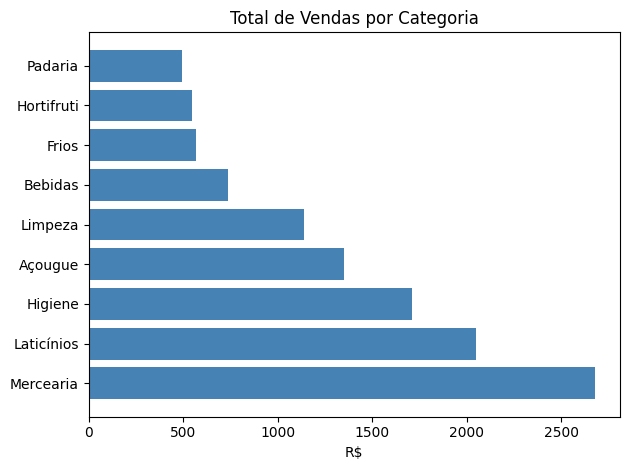

In [82]:
vendas_cat = df_limpo.groupby('Categoria')['Valor Líquido'].sum().sort_values(ascending=False)
plt.barh(vendas_cat.index, vendas_cat.values, color='steelblue')
plt.title('Total de Vendas por Categoria')
plt.xlabel('R$')
plt.tight_layout()
plt.show()